<h1 style="text-align:center;">B0801_RAKFKQLL</h1>

In [91]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB import MMCIFParser, PDBIO, PDBParser, Superimposer, Model, Structure
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1
from scipy.spatial import cKDTree

from collections import defaultdict

# Prepare AF3 input

In [8]:
df = pd.read_csv('/Users/roessner/Documents/PostDoc/Data/TCR_data/EpitopeSpecific/PublicDatabases/full_dataset_TCR-epitope_clean.csv')
df = df[df['model'] == 'B0801_RAKFKQLL']
df = df[['TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB']]
df = df.dropna()

tcr_ids = np.array([f'tcr_{i+1:04d}' for i in range(len(df))])
df.insert(0, 'id', tcr_ids)
df['peptide'] = 'RAKFKQLL'
df['species'] = 'HomoSapiens'
df['MHC'] = 'HLA_B0801'
df.to_csv('B0801_RAKFKQLL.csv', index=False)

# Compute relative SASA for epitope residues from AF models

In [ ]:
# normalize SASA to residue size
max_sasa = {
    'A': 121, 'R': 265, 'N': 187, 'D': 187,
    'C': 148, 'Q': 214, 'E': 214, 'G': 97,
    'H': 216, 'I': 195, 'L': 191, 'K': 230,
    'M': 203, 'F': 228, 'P': 154, 'S': 143,
    'T': 163, 'W': 264, 'Y': 255, 'V': 165
}

sequence = 'RAKFKQLL'
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]

parser = MMCIFParser(QUIET=True)
results = {'Position':[],
           'SASA':[],
           'rSASA':[],
           'id':[]}

cif_files = glob.glob('B0801_RAKFKQLL/AF3_outputs/*/*.cif')
cif_files.sort()

for file in cif_files:
    tcr_id = os.path.basename(file).split('_')[:2]
    tcr_id = '_'.join(tcr_id)

    structure = parser.get_structure('structure', file)
    
    sr = ShrakeRupley()
    sr.compute(structure, level="R")  # R = per residue
    
    for model in structure:
        for chain in model:
            if chain.id == "PEPTIDE":   # change if needed
                for residue in chain:
                    results['Position'].append(residue.id[1])
                    results['SASA'].append(residue.sasa)
                    wt_aa = sequence[residue.id[1] - 1]
                    results['rSASA'].append(residue.sasa / max_sasa[wt_aa])
                    results['id'].append(tcr_id)

df = pd.DataFrame(results)
df.to_pickle('relative_sasa.pkl')

   Position      SASA     rSASA        id  AF3_iptm_pair_mean
0         1  8.954657  0.033791  tcr_0001              0.7875
1         2  1.071459  0.008855  tcr_0001              0.7875
2         3  7.131729  0.031008  tcr_0001              0.7875
3         4  0.000000  0.000000  tcr_0001              0.7875
4         5  3.622885  0.015752  tcr_0001              0.7875


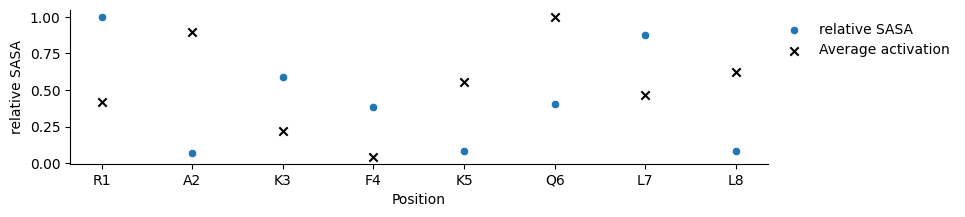

In [44]:
sequence = 'RAKFKQLL'
df = pd.read_pickle('relative_sasa.pkl')
df_anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df = pd.merge(df, df_anno, on='id')

df_avg = df.groupby('Position')[['SASA', 'rSASA']].mean().reset_index()
df_avg['rSASA'] = df_avg['rSASA'] / df_avg['rSASA'].max() # scale (maximum to one)

# exclude unreliable AF3 models
df_subset = df[df['AF3_iptm_pair_mean'] > 0.5]
print(df_subset.head())
df_avg_subset = df_subset.groupby('Position')[['SASA', 'rSASA']].mean().reset_index()
df_avg_subset['rSASA'] = df_avg_subset['rSASA'] / df_avg_subset['rSASA'].max() # scale (maximum to one)

# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  

fig, ax = plt.subplots(1,1, figsize=(9,2), sharex=True, sharey=True)

#sns.scatterplot(df_avg, x='Position', y='rSASA', ax=ax)
sns.scatterplot(df_avg_subset, x='Position', y='rSASA', ax=ax, label='relative SASA')
sns.scatterplot(data=df_activation, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='')
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
ax.set_ylabel('relative SASA')
sns.despine()

# Filter models by epitope / CDR pLDDT

In [71]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    # collect epitope CA coordinates
    epitope_ca = []
    for chain_id in epitope_chains:
        chain = model[chain_id]
        for res in chain:
            if res.id[0] == " " and "CA" in res:
                epitope_ca.append(res["CA"].get_coord())
    epitope_ca = np.array(epitope_ca)

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_plddt[chain_label] = {}

        for i, cdr_key in enumerate(
            [f"CDR1{chain_label[-1]}",
             f"CDR2{chain_label[-1]}",
             f"CDR3{chain_label[-1]}"], 1):

            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr_key} not found in {chain_id} of {cif_path}")
                return None

            end_idx = start_idx + L

            plddts = []

            for res in residues[start_idx:end_idx]:
                ca_coord = res["CA"].get_coord()

                # compute distance to all epitope CA atoms
                dists = np.linalg.norm(epitope_ca - ca_coord, axis=1)

                if np.any(dists <= threshold):
                    plddts.append(res["CA"].get_bfactor())

            if len(plddts) > 0:
                cdr_plddt[chain_label][f"cdr{i}"] = np.mean(plddts) / 100
            else:
                cdr_plddt[chain_label][f"cdr{i}"] = np.nan

    return cdr_plddt


In [80]:
parser = MMCIFParser(QUIET=True)

results = {'id':[],
           'epitope_plddt':[],
           'cdr_plddt':[]}

cif_files = glob.glob('B0801_RAKFKQLL/AF3_outputs/*/*.cif')
cif_files.sort()

# CDR sequences
genes = ['TRAV', 'TRBV']
df_anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_input.txt', sep='\t')
df_anno = df_anno.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})
for gene in genes:
    df = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
    df = df.rename(columns={df.columns[0]:gene})
    df[f'CDR1{gene[-2]}'] = df['CDR1'].str.replace('-', '', regex=False)
    df[f'CDR2{gene[-2]}'] = df['CDR2'].str.replace('-', '', regex=False)
    df = df[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

    df_anno = pd.merge(df_anno, df, on=gene)

# annotate CDR plddt
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df['cdr_plddt'] = np.nan

for file in cif_files:
    tcr_id = os.path.basename(file).split('_')[:2]
    tcr_id = '_'.join(tcr_id)
    results['id'].append(tcr_id)

    structure = parser.get_structure('structure', file)
    model = structure[0]
    
    # peptide plddt
    peptide_chain = model['PEPTIDE']

    plddts = []
    for residue in peptide_chain:
        for atom in residue:
            plddts.append(atom.get_bfactor())

    results['epitope_plddt'].append(np.mean(plddts))

    # get cdr sequences
    row = df_anno[df_anno["id"] == tcr_id]
    cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

    # get cdr plddt (for residues colose to epitope)
    cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10)

    cdr_val = min(v for d in cdr_plddts.values() for v in d.values())
    df.loc[df['id'] == tcr_id, 'cdr_plddt'] = cdr_val

df.to_pickle('B0801_RAKFKQLL/B0801_RAKFKQLL_output_plddt.pkl')

     Position       SASA     rSASA        id  AF3_iptm_pair_mean  cdr_plddt
544         1  19.890541  0.075059  tcr_0069              0.8225    0.92815
545         2   0.000000  0.000000  tcr_0069              0.8225    0.92815
546         3   9.318906  0.040517  tcr_0069              0.8225    0.92815
547         4  14.377499  0.063059  tcr_0069              0.8225    0.92815
548         5   2.415256  0.010501  tcr_0069              0.8225    0.92815


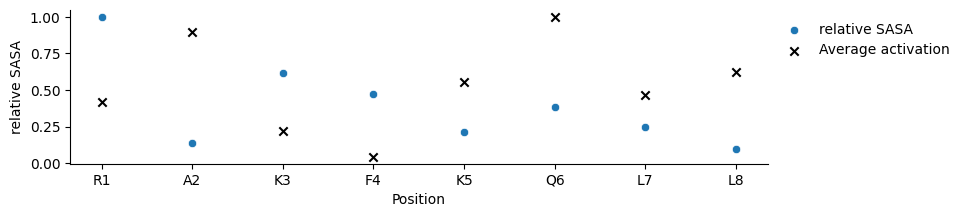

In [108]:
sequence = 'RAKFKQLL'
df = pd.read_pickle('relative_sasa.pkl')
df_anno = pd.read_pickle('B0801_RAKFKQLL/B0801_RAKFKQLL_output_plddt.pkl')
df = pd.merge(df, df_anno, on='id')

df_avg = df.groupby('Position')[['SASA', 'rSASA']].mean().reset_index()
df_avg['rSASA'] = df_avg['rSASA'] / df_avg['rSASA'].max() # scale (maximum to one)

# exclude unreliable AF3 models
plddt_threshold = 0.9 # bindcraft filter
df_subset = df[df['cdr_plddt'] > plddt_threshold]
print(df_subset.head())
df_avg_subset = df_subset.groupby('Position')[['SASA', 'rSASA']].mean().reset_index()
df_avg_subset['rSASA'] = df_avg_subset['rSASA'] / df_avg_subset['rSASA'].max() # scale (maximum to one)

# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  

fig, ax = plt.subplots(1,1, figsize=(9,2), sharex=True, sharey=True)

#sns.scatterplot(df_avg, x='Position', y='rSASA', ax=ax)
sns.scatterplot(df_avg_subset, x='Position', y='rSASA', ax=ax, label='relative SASA')
sns.scatterplot(df_activation, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
ax.set_ylabel('relative SASA')
sns.despine()

# Compute hydrogen bonding for polar residues

In [13]:
# Simplified donor/acceptor definitions
DONORS = {"N", "ND2", "NE2", "NZ", "NE", "NH1", "NH2"}  # common donor atoms in sidechains/backbone N-H
ACCEPTORS = {"O", "OD1", "OD2", "OE1", "OE2", "OG", "OG1"}  # common acceptors include O and sometimes N

def find_peptide_tcr_hbonds(cif_file,
                            peptide_chain="PEPTIDE",
                            tcr_chains=("TCRA","TCRB"),
                            cutoff=3.5):
    
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", cif_file)
    model = structure[0]
    peptide = model[peptide_chain]

    # collect TCR atoms with their donor/acceptor status
    tcr_atoms = []
    tcr_coords = []
    tcr_types = []  # "donor" or "acceptor"

    for chain_id in tcr_chains:
        for atom in model[chain_id].get_atoms():
            if atom.element not in {"N", "O"}:
                continue
            tcr_atoms.append(atom)
            tcr_coords.append(atom.coord)
            if atom.name in DONORS:
                tcr_types.append("donor")
            else:
                tcr_types.append("acceptor")

    tcr_coords = np.array(tcr_coords)
    tree = cKDTree(tcr_coords)

    hbonds = []

    # loop peptide atoms
    for res in peptide:
        for atom in res:
            if atom.element not in {"N", "O"}:
                continue

            # determine if peptide atom is donor or acceptor
            if atom.name in DONORS:
                pep_type = "donor"
            else:
                pep_type = "acceptor"

            coord = atom.coord

            # query nearby TCR atoms
            idxs = tree.query_ball_point(coord, cutoff)

            for idx in idxs:
                t_atom = tcr_atoms[idx]
                t_type = tcr_types[idx]

                # only donor-acceptor pairs
                if pep_type == t_type:
                    continue

                dist = np.linalg.norm(coord - t_atom.coord)

                hbonds.append({
                    "pep_res": res.get_resname(),
                    "pep_pos": res.id[1],
                    "pep_atom": atom.name,
                    "tcr_chain": t_atom.get_parent().get_parent().id,
                    "tcr_res": t_atom.get_parent().get_resname(),
                    "tcr_pos": t_atom.get_parent().id[1],
                    "tcr_atom": t_atom.name,
                    "dist": dist
                })

    return hbonds

In [116]:
sequence = 'RAKFKQLL'
results = {'Position':[],
           'hbonds':[],
           'id':[]}

cif_files = glob.glob('B0801_RAKFKQLL/AF3_outputs/*/*.cif')
cif_files.sort()

for file in cif_files:
    tcr_id = os.path.basename(file).split('_')[:2]
    tcr_id = '_'.join(tcr_id)

    hbonds = find_peptide_tcr_hbonds(file)

    counts = defaultdict(int)
    for h in hbonds:
        counts[h["pep_pos"]] += 1

    for pos in range(1, len(sequence) + 1):
        if pos in counts:
            results['Position'].append(pos)
            results['hbonds'].append(counts[pos])
            results['id'].append(tcr_id)
        else:
            results['Position'].append(pos)
            results['hbonds'].append(0)
            results['id'].append(tcr_id)

df = pd.DataFrame(results)
df.to_pickle('hbonds.pkl')

344


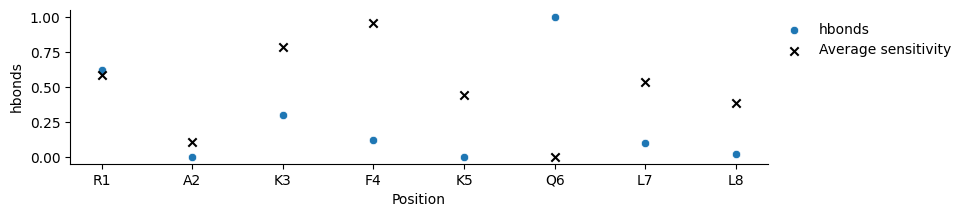

In [118]:
sequence = 'RAKFKQLL'
df = pd.read_pickle('hbonds.pkl')
df_anno = pd.read_pickle('B0801_RAKFKQLL/B0801_RAKFKQLL_output_plddt.pkl')
df = pd.merge(df, df_anno, on='id')

df_avg = df.groupby('Position')[['hbonds']].mean().reset_index()
df_avg['hbonds'] = df_avg['hbonds'] / df_avg['hbonds'].max() # scale (maximum to one)

# exclude unreliable AF3 models
df_subset = df[df['cdr_plddt'] > 0.8]
print(len(df_subset))
df_avg_subset = df_subset.groupby('Position')[['hbonds']].mean().reset_index()
df_avg_subset['hbonds'] = df_avg_subset['hbonds'] / df_avg_subset['hbonds'].max() # scale (maximum to one)

# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore']

fig, ax = plt.subplots(1,1, figsize=(9,2), sharex=True, sharey=True)

sns.scatterplot(df_avg_subset, x='Position', y='hbonds', ax=ax, label='hbonds')
sns.scatterplot(df_activation, x='Position', y='SensitivityScore', ax=ax, label='Average sensitivity', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
ax.set_ylabel('hbonds')
sns.despine()

# Compute SASA / hbonds for experimentally tested TCR

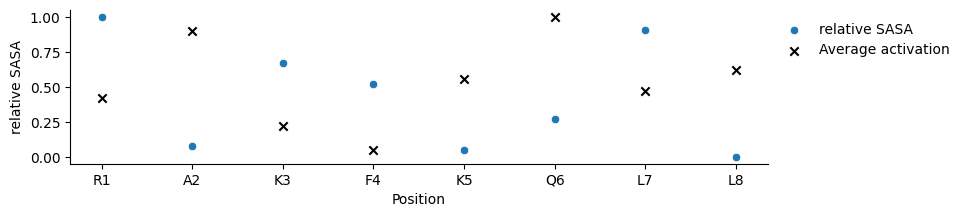

In [12]:
# normalize SASA to residue size
max_sasa = {
    'A': 121, 'R': 265, 'N': 187, 'D': 187,
    'C': 148, 'Q': 214, 'E': 214, 'G': 97,
    'H': 216, 'I': 195, 'L': 191, 'K': 230,
    'M': 203, 'F': 228, 'P': 154, 'S': 143,
    'T': 163, 'W': 264, 'Y': 255, 'V': 165
}

sequence = 'RAKFKQLL'
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_input.txt', sep='\t')
df = pd.merge(df, anno, on='id')

df_exp = df[(df['TRAV'] == 'TRAV13-1') & (df['TRAJ'] == 'TRAJ50') & (df['TRBV'] == 'TRBV7-9') & (df['TRBJ'] == 'TRBJ1-1') & (df['cdr3_TRA'] == 'CAASETSYDKVIF') & (df['cdr3_TRB'] == 'CASSLLGQKDTEAFF') ]

parser = MMCIFParser(QUIET=True)
results = {'Position':[],
           'SASA':[],
           'rSASA':[],
           'id':[]}

tcr_id = df_exp["id"].values[0]
file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}/{tcr_id}_model.cif'
structure = parser.get_structure('structure', file)

sr = ShrakeRupley()
sr.compute(structure, level="R")  # R = per residue

for model in structure:
    for chain in model:
        if chain.id == "PEPTIDE":   # change if needed
            for residue in chain:
                results['Position'].append(residue.id[1])
                results['SASA'].append(residue.sasa)
                wt_aa = sequence[residue.id[1] - 1]
                results['rSASA'].append(residue.sasa / max_sasa[wt_aa])
                results['id'].append(tcr_id)

df = pd.DataFrame(results)
df['rSASA'] = df['rSASA'] / df['rSASA'].max() # scale (maximum to one)

# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  

fig, ax = plt.subplots(1,1, figsize=(9,2), sharex=True, sharey=True)

#sns.scatterplot(df_avg, x='Position', y='rSASA', ax=ax)
sns.scatterplot(df, x='Position', y='rSASA', ax=ax, label='relative SASA')
sns.scatterplot(df_activation, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
ax.set_ylabel('relative SASA')
sns.despine()

         id  AF3_iptm_pair_mean      TRAV    TRAJ     TRBV     TRBJ  \
2  tcr_0003                 0.7  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   

        cdr3_TRA         cdr3_TRB   peptide      species        MHC  \
2  CAASETSYDKVIF  CASSLLGQKDTEAFF  RAKFKQLL  HomoSapiens  HLA_B0801   

  MHC_allele_a MHC_allele_b  
2    HLA_B0801          B2M  


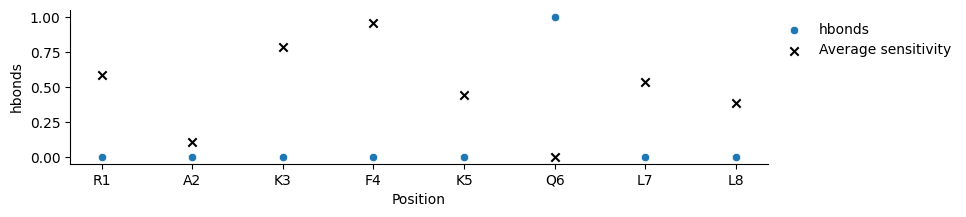

In [ ]:
sequence = 'RAKFKQLL'
results = {'Position':[],
           'hbonds':[],
           'id':[]}

sequence = 'RAKFKQLL'
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_input.txt', sep='\t')
df = pd.merge(df, anno, on='id')

df_exp = df[(df['TRAV'] == 'TRAV13-1') & (df['TRAJ'] == 'TRAJ50') & (df['TRBV'] == 'TRBV7-9') & (df['TRBJ'] == 'TRBJ1-1') & (df['cdr3_TRA'] == 'CAASETSYDKVIF') & (df['cdr3_TRB'] == 'CASSLLGQKDTEAFF') ]

print(df_exp)
tcr_id = df_exp["id"].values[0]
file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}/{tcr_id}_model.cif'
structure = parser.get_structure('structure', file)

hbonds = find_peptide_tcr_hbonds(file, cutoff=4)

counts = defaultdict(int)
for h in hbonds:
    counts[h["pep_pos"]] += 1

for pos in range(1, len(sequence) + 1):
    if pos in counts:
        results['Position'].append(pos)
        results['hbonds'].append(counts[pos])
        results['id'].append(tcr_id)
    else:
        results['Position'].append(pos)
        results['hbonds'].append(0)
        results['id'].append(tcr_id)

df = pd.DataFrame(results)

# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore']

fig, ax = plt.subplots(1,1, figsize=(9,2), sharex=True, sharey=True)

sns.scatterplot(df, x='Position', y='hbonds', ax=ax, label='hbonds')
sns.scatterplot(df_activation, x='Position', y='SensitivityScore', ax=ax, label='Average sensitivity', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
ax.set_ylabel('hbonds')
sns.despine()


In [25]:
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_input.txt', sep='\t')
df = pd.merge(df, anno, on='id')

df_exp = df[(df['TRAV'] == 'TRAV13-1') & (df['TRAJ'] == 'TRAJ50') & (df['TRBV'] == 'TRBV7-9') & (df['TRBJ'] == 'TRBJ1-1')]
print(df_exp)

           id  AF3_iptm_pair_mean      TRAV    TRAJ     TRBV     TRBJ  \
2    tcr_0003              0.7000  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
26   tcr_0027              0.7675  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
61   tcr_0062              0.7300  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
90   tcr_0091              0.6275  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
102  tcr_0103              0.6725  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
104  tcr_0105              0.7650  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
111  tcr_0112              0.7200  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
122  tcr_0123              0.6950  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
157  tcr_0158              0.7375  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
178  tcr_0179              0.6800  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
196  tcr_0197              0.4900  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
216  tcr_0217              0.7525  TRAV13-1  TRAJ50  TRBV7-9  TRBJ1-1   
226  tcr_0227              0.7625  TRAV13-1  TRAJ50

# Compare overall confidence with YF public data

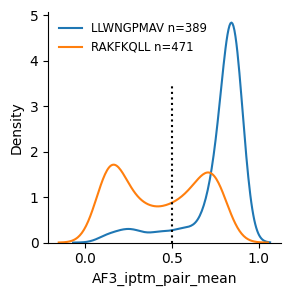

In [42]:
df_YF = pd.read_csv('../260202_YF-modes/data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3.tsv', sep='\t')
df_RAK = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')

fix, ax = plt.subplots(1, 1, figsize=(3,3))
sns.kdeplot(df_YF, x='AF3_iptm_pair_mean', label=f'LLWNGPMAV n={len(df_YF)}', ax=ax)
sns.kdeplot(df_RAK, x='AF3_iptm_pair_mean', label=f'RAKFKQLL n={len(df_RAK)}', ax=ax)

ax.legend(loc='upper left', frameon=False, fontsize='small')
ymax_line = (3.5 - ax.get_ylim()[0]) / (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.axvline(0.5, ymax=ymax_line, color='black', linestyle=':')
sns.despine()

In [49]:
df_YF = pd.read_csv('../260202_YF-modes/data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3.tsv', sep='\t')
df_RAK = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')

lst = [df_YF, df_RAK]

results = {
    'tcr_id' : [],
    'peptide_plddt' : [],
    'peptide' : []
}

for cnt, df in enumerate(lst):
    df = df[df['AF3_iptm_pair_mean'] > 0.5]
    tcr_ids = df['id'].values

    for tcr_id in tcr_ids:
        if cnt == 0:
            cif_file = f'../260202_YF-modes/data_julien/Public_Data/YF_public_pairedData_20251010/model/{tcr_id}_model.cif'
        else:
            cif_file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}/{tcr_id}_model.cif'

        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure("model", cif_file)
        model = structure[0]
        peptide = model['PEPTIDE']
        
        plddts = []
        for atom in peptide.get_atoms():
            plddts.append(atom.get_bfactor())

        results['tcr_id'].append(tcr_id)
        results['peptide_plddt'].append(np.mean(plddts))
        if cnt == 0:
            results['peptide'].append('LLWNGPMAV')
        else:
            results['peptide'].append('RAKFKQLL')

df = pd.DataFrame(results)    
df.to_pickle('peptide_plddt.pkl')

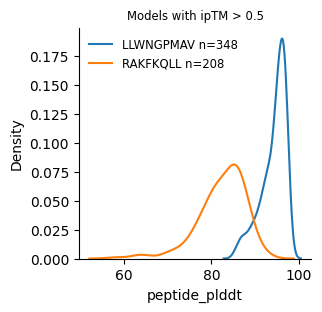

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3,3))

df = pd.read_pickle('peptide_plddt.pkl')
peptides = ['LLWNGPMAV', 'RAKFKQLL']

for peptide in peptides:
    tmp = df[df['peptide'] == peptide]
    sns.kdeplot(tmp, x='peptide_plddt', label=f'{peptide} n={len(tmp)}', ax=ax)

ax.set_title('Models with ipTM > 0.5', fontsize='small')   
ax.legend(loc='upper left', frameon=False, fontsize='small')
sns.despine()

# Peptide position confidence 

In [85]:
df_YF = pd.read_csv('../260202_YF-modes/data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3.tsv', sep='\t')
df_RAK = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')
anno = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_input.txt', sep='\t')
df_RAK = pd.merge(df_RAK, anno, on='id')

lst = [df_YF, df_RAK]

results = {
    'tcr_id' : [],
    'resid' : [],
    'peptide_plddt' : [],
    'peptide' : []
}

for cnt, df in enumerate(lst):
    df = df[df['AF3_iptm_pair_mean'] > 0.5]
    """
    if cnt == 0:
        df = df[(df['TRAV'] == 'TRAV12-2') & (df['TRAJ'] == 'TRAJ30') & (df['TRBJ'] == 'TRBJ2-7')]
    else:
        df = df[(df['TRAV'] == 'TRAV13-1') & (df['TRAJ'] == 'TRAJ50') & (df['TRBV'] == 'TRBV7-9')]
    """
    tcr_ids = df['id'].values

    for tcr_id in tcr_ids:
        if cnt == 0:
            cif_file = f'../260202_YF-modes/data_julien/Public_Data/YF_public_pairedData_20251010/model/{tcr_id}_model.cif'
        else:
            cif_file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}/{tcr_id}_model.cif'

        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure("model", cif_file)
        model = structure[0]
        peptide = model['PEPTIDE']
        
        
        for residue in peptide:
            resid = residue.get_id()[1]
            plddts = []
            for atom in residue.get_atoms():
                plddts.append(atom.get_bfactor())

            results['resid'].append(resid)
            results['tcr_id'].append(tcr_id)
            results['peptide_plddt'].append(np.mean(plddts))
            if cnt == 0:
                results['peptide'].append('LLWNGPMAV')
            else:
                results['peptide'].append('RAKFKQLL')

df = pd.DataFrame(results)    
df.to_pickle('peptide_plddt_per_residue.pkl')

   resid  peptide_plddt
0      1       0.000000
1      2       1.000000
2      3       0.513031
3      4       0.809274
4      5       0.607272
5      6       0.070649
6      7       0.482607
7      8       0.940448


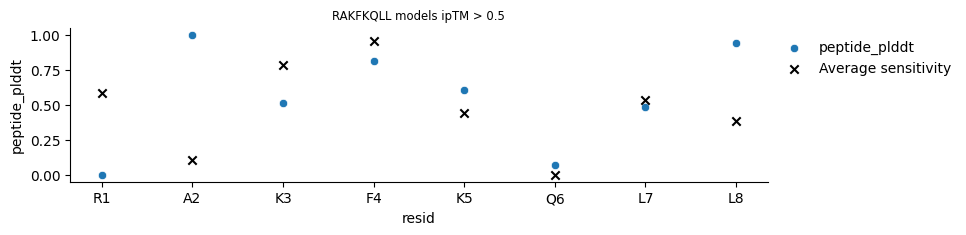

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(9,2))

df = pd.read_pickle('peptide_plddt_per_residue.pkl')
peptide = 'RAKFKQLL'

df = df[df['peptide'] == peptide]
df_avg = df.groupby('resid')['peptide_plddt'].mean().reset_index()
df_avg['peptide_plddt'] = (
    (df_avg['peptide_plddt'] - df_avg['peptide_plddt'].min()) /
    (df_avg['peptide_plddt'].max() - df_avg['peptide_plddt'].min())
)
print(df_avg)
# experimental data
df_activation = pd.read_csv('RAK_Xscan.csv', sep=';')
df_activation['Position'] = df_activation['Position'].str[-1].astype(int)
df_activation['ActivationScore'] =  df_activation['ActivationScore'].astype(float)
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)  
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore']

sns.scatterplot(df_avg, x='resid', y='peptide_plddt', ax=ax, label='peptide_plddt')
sns.scatterplot(df_activation, x='Position', y='SensitivityScore', ax=ax, label='Average sensitivity', marker='x', color='black', linewidth=1.5)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
ax.set_title('RAKFKQLL models ipTM > 0.5', fontsize='small')   
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
sns.despine()

# Peptide position RMSF 

In [94]:
df = pd.read_csv('B0801_RAKFKQLL/B0801_RAKFKQLL_output.txt', sep='\t')
df = df[df['AF3_iptm_pair_mean'] > 0.5]

tcr_ids = df['id'].values

for tcr_id in tcr_ids:
    cif_file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}/{tcr_id}_model.cif'

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", cif_file)
    model = structure[0]
    peptide = model['PEPTIDE']
    # rename chain to a single letter
    peptide.id = 'P'

    new_structure = Structure.Structure("peptide")
    new_model = Model.Model(0)
    new_model.add(peptide)
    new_structure.add(new_model)

    # save to PDB
    io = PDBIO()
    io.set_structure(new_structure)
    out_file = f'B0801_RAKFKQLL/AF3_outputs/{tcr_id}_peptide.pdb'
    io.save(out_file)

/Users/roessner/miniconda3/envs/wheeler/lib/python3.12/site-packages/MDAnalysis/coordinates/base.py:725: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt
/Users/roessner/miniconda3/envs/wheeler/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:447: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[i] = ts.time
/Users/roessner/miniconda3/envs/wheeler/lib/python3.12/site-packages/MDAnalysis/analysis/rms.py:887: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_6467/256181835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')


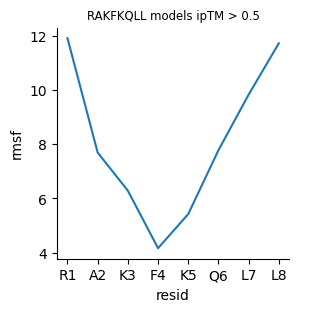

In [104]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms

files = glob.glob(f'B0801_RAKFKQLL/AF3_outputs/*_peptide.pdb')
files.sort()

u = mda.Universe(files[0], files)

# select peptide atoms (all heavy atoms)
peptide = u.select_atoms('all')  

# align all frames to the first frame
rms_align = rms.RMSF(peptide).run()  # this computes RMSF directly

# RMSF per atom
atom_rmsf = rms_align.rmsf  # numpy array, length = number of atoms

# compute RMSF per residue
res_rmsf = []
resids = []
for res in peptide.residues:
    res_atoms = res.atoms
    res_rmsf.append(atom_rmsf[res_atoms.indices].mean())  # average RMSF of atoms in residue
    resids.append(res.resid)

# convert to numpy array
res_rmsf = np.array(res_rmsf)

# optionally make a DataFrame
df_rmsf = pd.DataFrame({'resid': resids, 'rmsf': res_rmsf})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.lineplot(df_rmsf, x='resid', y='rmsf', ax=ax)

ax.legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
ax.set_title('RAKFKQLL models ipTM > 0.5', fontsize='small')   
new_labels = [f'{sequence[i]}{i+1}' for i in range(len(sequence))]
ax.set_xticks(range(1, len(new_labels)+1))
ax.set_xticklabels(new_labels)
sns.despine()